# Exploratory Data Analysis - Appliance Energy Prediction

This notebook explores the Appliance Energy Prediction dataset: trends, seasonality, correlations, missing values and outliers. It mirrors the logic in `src/eda.py` and `src/data_preprocessing.py` so the figures embedded in the report can be regenerated interactively.

Run from the repository root (so the relative paths resolve).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent / 'src'))
from data_preprocessing import load_data, drop_noise_columns, handle_missing_values, treat_outliers, basic_summary

sns.set_theme(style='whitegrid')
RAW = Path.cwd().parent / 'data' / 'raw' / 'energy_data_set.csv'

## 1. Load and inspect

In [2]:
df = load_data(RAW)
print('Shape:', df.shape)
print('Date range:', df.index.min(), '->', df.index.max())
df.head()

Shape: (19735, 28)
Date range: 2016-01-11 17:00:00 -> 2016-05-27 18:00:00


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
# Per-column summary: dtypes, missing values, ranges
basic_summary(df)

,dtype,n_missing,pct_missing,n_unique,min,max,mean
Appliances,int64,0,0.0,92,10.000000,1080.000000,97.694958
lights,int64,0,0.0,8,0.000000,70.000000,3.801875
T1,float64,0,0.0,722,16.790000,26.260000,21.686571
RH_1,float64,0,0.0,2547,27.023333,63.360000,40.259739
T2,float64,0,0.0,1650,16.100000,29.856667,20.341219
RH_2,float64,0,0.0,3376,20.463333,56.026667,40.420420
T3,float64,0,0.0,1426,17.200000,29.236000,22.267611
RH_3,float64,0,0.0,2618,28.766667,50.163333,39.242500
T4,float64,0,0.0,1390,15.100000,26.200000,20.855335
RH_4,float64,0,0.0,2987,27.660000,51.090000,39.026904


**Observations.** There are no missing values in the raw file, and `rv1`/`rv2` are random-noise columns (dropped below). The target `Appliances` is strongly right-skewed.

In [4]:
df = handle_missing_values(drop_noise_columns(df))
df['Appliances'].describe()

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64

## 2. Target trend over time

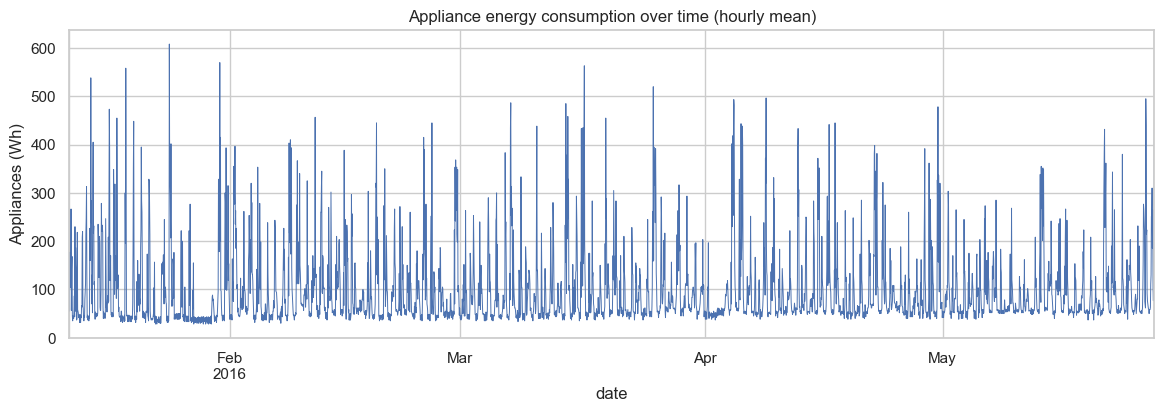

In [5]:
plt.figure(figsize=(14, 4))
df['Appliances'].resample('1h').mean().plot(linewidth=0.7)
plt.title('Appliance energy consumption over time (hourly mean)')
plt.ylabel('Appliances (Wh)')
plt.show()

## 3. Distribution of the target

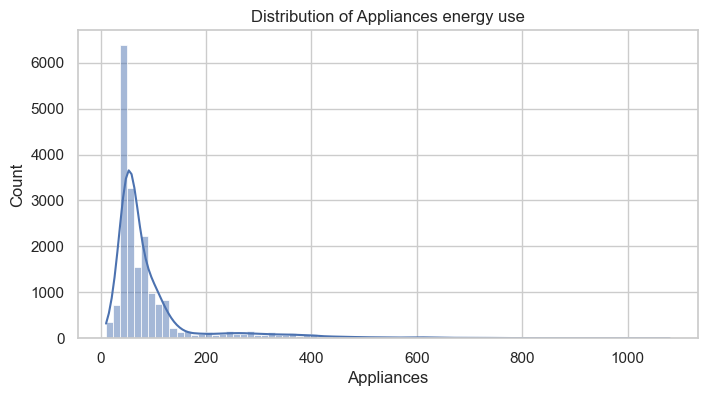

Skew: 3.39


In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Appliances'], bins=80, kde=True)
plt.title('Distribution of Appliances energy use')
plt.show()
print('Skew:', round(df['Appliances'].skew(), 2))

## 4. Seasonality: hour of day and day of week

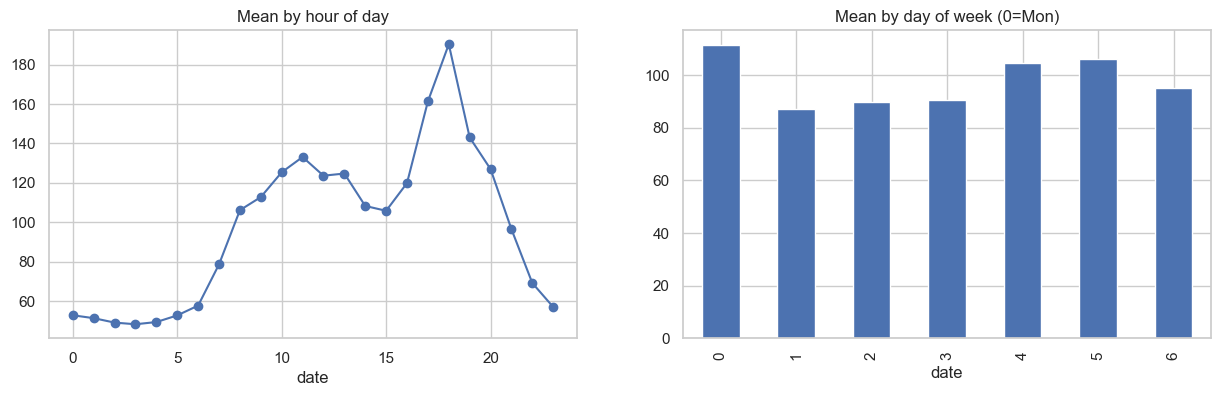

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
df.groupby(df.index.hour)['Appliances'].mean().plot(marker='o', ax=ax[0], title='Mean by hour of day')
df.groupby(df.index.dayofweek)['Appliances'].mean().plot(kind='bar', ax=ax[1], title='Mean by day of week (0=Mon)')
plt.show()

**Observations.** Consumption is lowest overnight, ramps up in the morning and peaks in the early evening (~18:00). Weekends differ slightly from weekdays — motivating the hour, day-of-week and weekend features.

## 5. Correlation structure

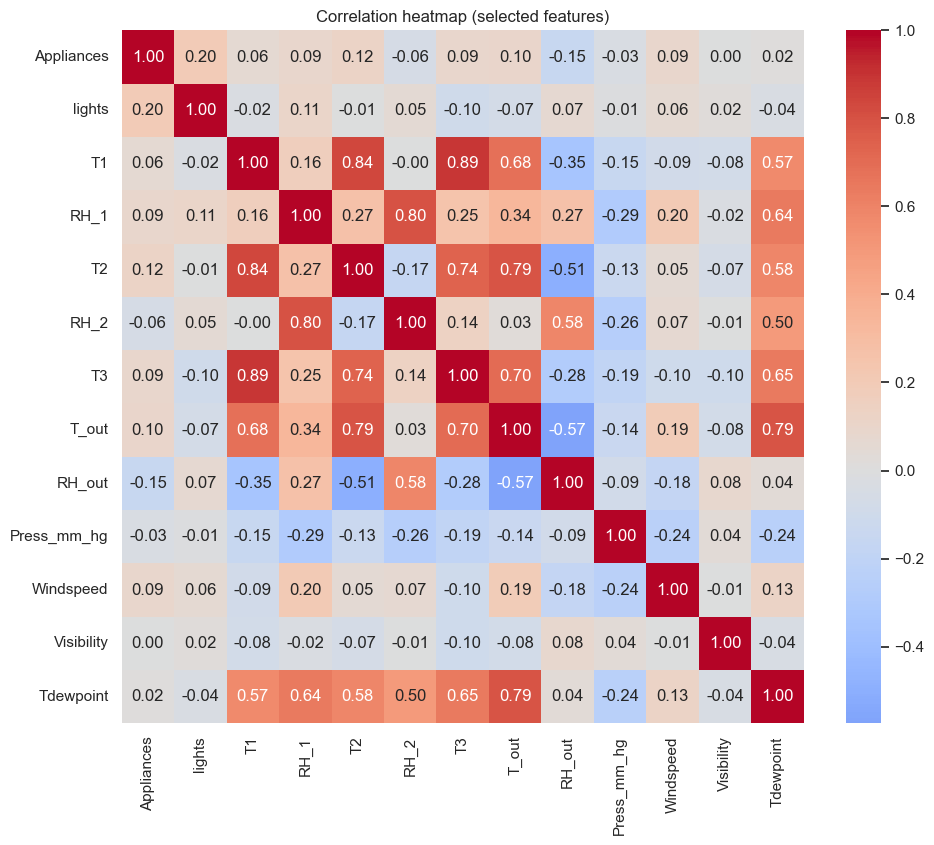

In [8]:
cols = ['Appliances','lights','T1','RH_1','T2','RH_2','T3','T_out','RH_out','Press_mm_hg','Windspeed','Visibility','Tdewpoint']
cols = [c for c in cols if c in df.columns]
plt.figure(figsize=(11, 9))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap (selected features)')
plt.show()

**Observations.** No single environmental sensor is strongly correlated with `Appliances` (the strongest are `lights` and indoor temperatures), which is why **lagged** values of the target itself end up being the most predictive features. This motivates the time-series feature engineering and sequence models.

## 6. Outliers

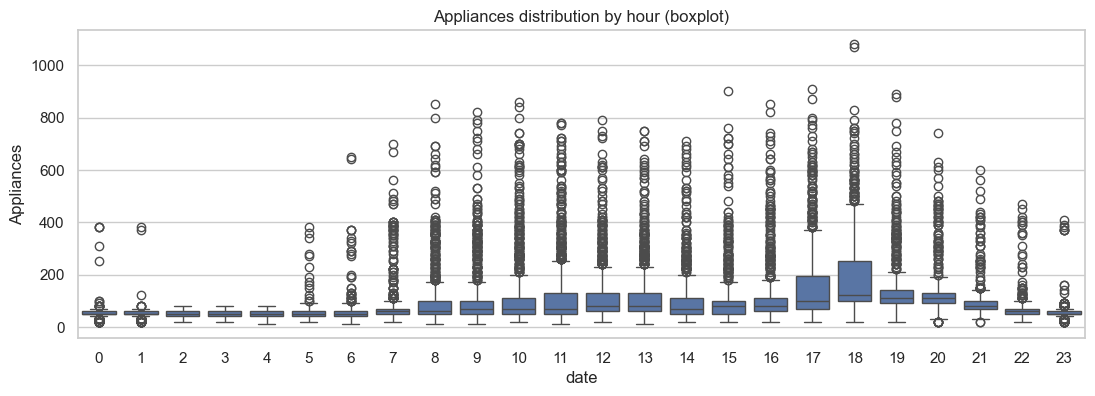

,column,n_outliers,pct
0,lights,4483,22.72
1,Visibility,2522,12.78
2,RH_5,1330,6.74
3,T2,546,2.77
4,T1,515,2.61
5,T6,515,2.61
6,T_out,436,2.21
7,RH_out,239,1.21
8,RH_2,235,1.19
9,Press_mm_hg,219,1.11


In [9]:
plt.figure(figsize=(13, 4))
sns.boxplot(x=df.index.hour, y=df['Appliances'])
plt.title('Appliances distribution by hour (boxplot)')
plt.show()

_, report = treat_outliers(df)
report.head(10)

**Conclusion.** High-energy events are concentrated in waking/evening hours and are genuine (not sensor errors), so we winsorise only the *environmental sensors* by IQR and leave the target untouched. See `src/data_preprocessing.py` for the implementation.